In [9]:
!pip install --upgrade kaggle -q

In [11]:
# import os
# from google.colab import userdata

# os.environ["KAGGLE_TOKEN"] = userdata.get("KAGGLE_TOKEN")
# !kaggle datasets download -d abhisheksjha/time-series-air-quality-data-of-india-2010-2023 --unzip -p /content/air_quality
import os
from google.colab import userdata
import requests
import zipfile

# Auth
token = userdata.get('KAGGLE_TOKEN')
os.environ['KAGGLE_TOKEN'] = token

# Download via requests directly
url = "https://www.kaggle.com/api/v1/datasets/download/abhisheksjha/time-series-air-quality-data-of-india-2010-2023"
headers = {"Authorization": f"Bearer {token}"}

print("Downloading...")
r = requests.get(url, headers=headers, stream=True)
print(f"Status: {r.status_code}")

with open('/content/air_quality.zip', 'wb') as f:
    for chunk in r.iter_content(chunk_size=8192):
        f.write(chunk)

print("Extracting...")
os.makedirs('/content/air_quality', exist_ok=True)
with zipfile.ZipFile('/content/air_quality.zip', 'r') as z:
    z.extractall('/content/air_quality')

print("Done!")
print(os.listdir('/content/air_quality')[:5])

Downloading...
Status: 200
Extracting...
Done!
['MH028.csv', 'UP021.csv', 'MP001.csv', 'KA003.csv', 'KA029.csv']


In [12]:
print(os.listdir('/content/air_quality'))

['MH028.csv', 'UP021.csv', 'MP001.csv', 'KA003.csv', 'KA029.csv', 'KA008.csv', 'TN016.csv', 'DL027.csv', 'BR013.csv', 'HR022.csv', 'UP030.csv', 'CG003.csv', 'UP005.csv', 'TN010.csv', 'RJ019.csv', 'UP035.csv', 'BR031.csv', 'TN026.csv', 'TN008.csv', 'BR007.csv', 'TG007.csv', 'TN005.csv', 'TN022.csv', 'HR009.csv', 'DL024.csv', 'AS004.csv', 'DL034.csv', 'UP009.csv', 'KA034.csv', 'TG002.csv', 'MP011.csv', 'UP036.csv', 'KA019.csv', 'DL015.csv', 'MH003.csv', 'HR004.csv', 'RJ005.csv', 'AP003.csv', 'KL005.csv', 'HR014.csv', 'TN017.csv', 'BR011.csv', 'HR006.csv', 'OR007.csv', 'MH010.csv', 'DL011.csv', 'BR024.csv', 'BR025.csv', 'TR002.csv', 'KA009.csv', 'MH005.csv', 'TN025.csv', 'TN020.csv', 'KA017.csv', 'MH004.csv', 'WB007.csv', 'PB006.csv', 'AS001.csv', 'CG001.csv', 'UP026.csv', 'DL009.csv', 'BR014.csv', 'RJ020.csv', 'TN019.csv', 'UP025.csv', 'HR018.csv', 'WB002.csv', 'OR010.csv', 'JH002.csv', 'DL016.csv', 'KA037.csv', 'MH036.csv', 'UP001.csv', 'DL007.csv', 'DL004.csv', 'UP029.csv', 'KA035.csv'

In [13]:
import pandas as pd

In [14]:
stations_info = pd.read_csv('/content/air_quality/stations_info.csv')
print(stations_info.shape)
print(stations_info.head())
print(stations_info.columns.tolist())

(453, 8)
  file_name           state               city agency  \
0     AP001  Andhra Pradesh           Tirupati  APPCB   
1     AP002  Andhra Pradesh         Vijayawada  APPCB   
2     AP003  Andhra Pradesh      Visakhapatnam  APPCB   
3     AP004  Andhra Pradesh  Rajamahendravaram  APPCB   
4     AP005  Andhra Pradesh          Amaravati  APPCB   

                          station_location start_month  start_month_num  \
0                      Tirumala, Tirupati         July                7   
1                 PWD Grounds, Vijayawada          May                5   
2          GVM Corporation, Visakhapatnam         July                7   
3  Anand Kala Kshetram, Rajamahendravaram    September                9   
4                  Secretariat, Amaravati     November               11   

   start_year  
0        2016  
1        2017  
2        2017  
3        2017  
4        2017  
['file_name', 'state', 'city', 'agency', 'station_location', 'start_month', 'start_month_num', 'start

In [15]:
target_cities = ["Delhi","Mumbai", "Chennai", "Hyderabad", "Bengaluru"]
for city in target_cities:
  matches = stations_info[stations_info["city"] == city]
  print(f"\n{city}: {len(matches)} stations")
  print(matches[["file_name", "station_location", "start_year"]])


Delhi: 40 stations
    file_name                            station_location  start_year
72      DL001                                 ITO, Delhi         2010
73      DL002                            Shadipur, Delhi         2010
74      DL003                            Sirifort, Delhi         2010
75      DL004                         NSIT Dwarka, Delhi         2010
76      DL005               IHBAS, Dilshad Garden, Delhi         2010
77      DL006                                 DTU, Delhi         2010
78      DL007                     Burari Crossing, Delhi         2010
79      DL008                    North Campus, DU, Delhi         2010
80      DL009                                Pusa, Delhi         2010
81      DL010                   CRRI Mathura Road, Delhi         2010
82      DL011                           Aya Nagar, Delhi         2010
83      DL012                         Mandir Marg, Delhi         2011
84      DL013                           R K Puram, Delhi         2011


In [16]:
df_mh002 = pd.read_csv("/content/air_quality/MH002.csv")
pm25_col = [c for c in df_mh002.columns if "PM2.5" in c][0]
print(f"MH002 non-null PM2.5: {df_mh002[pm25_col].notna().sum()}")
print(f"MH002 Shape: {df_mh002.shape}")

MH002 non-null PM2.5: 26115
MH002 Shape: (116112, 25)


In [17]:
df_mh002 = pd.read_csv('/content/air_quality/MH002.csv')
pm25_col = [c for c in df_mh002.columns if 'PM2.5' in c][0]

df_mh002 = df_mh002[['From Date', pm25_col]].copy()
df_mh002.columns = ['date', 'pm25']
df_mh002['date'] = pd.to_datetime(df_mh002['date'], errors='coerce')
df_mh002 = df_mh002.dropna(subset=['date']).set_index('date')

df_mh002_daily = df_mh002['pm25'].resample('D').mean().reset_index()
df_mh002_daily.columns = ['date', 'pm25']

print(f"Total days: {len(df_mh002_daily)}")
print(f"Days with data: {df_mh002_daily['pm25'].notna().sum()}")
print(f"Days missing: {df_mh002_daily['pm25'].isna().sum()} ({df_mh002_daily['pm25'].isna().mean()*100:.1f}%)")
print(f"Date range: {df_mh002_daily['date'].min().date()} to {df_mh002_daily['date'].max().date()}")

Total days: 4838
Days with data: 1231
Days missing: 3607 (74.6%)
Date range: 2010-01-01 to 2023-03-31


In [18]:
mumbai_2019_plus = stations_info[(stations_info['city'] == 'Mumbai') & (stations_info['start_year'] >= 2019)]

best_file, best_count = None, 0
for fname in mumbai_2019_plus['file_name']:
    df = pd.read_csv(f'/content/air_quality/{fname}.csv')
    pm_col = [c for c in df.columns if 'PM2.5' in c]
    if not pm_col:
        continue
    count = df[pm_col[0]].notna().sum()
    print(f"{fname}: non-null PM2.5={count}")
    if count > best_count:
        best_count = count
        best_file = fname

print(f"\nBest: {best_file} with {best_count} non-null readings")

MH013: non-null PM2.5=24428
MH014: non-null PM2.5=29447
MH015: non-null PM2.5=31308
MH016: non-null PM2.5=26627
MH017: non-null PM2.5=28457
MH018: non-null PM2.5=30529
MH019: non-null PM2.5=28966
MH020: non-null PM2.5=24623
MH021: non-null PM2.5=30514
MH022: non-null PM2.5=18118
MH023: non-null PM2.5=16085
MH025: non-null PM2.5=17276
MH026: non-null PM2.5=17908
MH029: non-null PM2.5=18401
MH033: non-null PM2.5=18499
MH034: non-null PM2.5=14454
MH035: non-null PM2.5=19019
MH036: non-null PM2.5=16081
MH037: non-null PM2.5=16430
MH039: non-null PM2.5=17821

Best: MH015 with 31308 non-null readings


In [19]:
df_mh015 = pd.read_csv('/content/air_quality/MH015.csv')
pm25_col = [c for c in df_mh015.columns if 'PM2.5' in c][0]

df_mh015 = df_mh015[['From Date', pm25_col]].copy()
df_mh015.columns = ['date', 'pm25']
df_mh015['date'] = pd.to_datetime(df_mh015['date'], errors='coerce')
df_mh015 = df_mh015.dropna(subset=['date']).set_index('date')

df_mh015_daily = df_mh015['pm25'].resample('D').mean().reset_index()
df_mh015_daily.columns = ['date', 'pm25']

print(f"Total days: {len(df_mh015_daily)}")
print(f"Days with data: {df_mh015_daily['pm25'].notna().sum()}")
print(f"Days missing: {df_mh015_daily['pm25'].isna().sum()} ({df_mh015_daily['pm25'].isna().mean()*100:.1f}%)")
print(f"Date range: {df_mh015_daily['date'].min().date()} to {df_mh015_daily['date'].max().date()}")

Total days: 1381
Days with data: 1348
Days missing: 33 (2.4%)
Date range: 2019-06-20 to 2023-03-31


In [20]:
final_stations = {
    'Delhi':     'DL005',
    'Chennai':   'TN002',
    'Hyderabad': 'TG001',
    'Bengaluru': 'KA003',
}

for city, fname in final_stations.items():
    df = pd.read_csv(f'/content/air_quality/{fname}.csv')
    pm25_col = [c for c in df.columns if 'PM2.5' in c][0]
    df = df[['From Date', pm25_col]].copy()
    df.columns = ['date', 'pm25']
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).set_index('date')

    daily = df['pm25'].resample('D').mean().reset_index()
    daily.columns = ['date', 'pm25']

    total = len(daily)
    missing = daily['pm25'].isna().sum()
    pct_missing = missing / total * 100

    print(f"{city} ({fname}): {total} days | missing={missing} ({pct_missing:.1f}%) | range: {daily['date'].min().date()} to {daily['date'].max().date()}")

Delhi (DL005): 4838 days | missing=1093 (22.6%) | range: 2010-01-01 to 2023-03-31
Chennai (TN002): 4838 days | missing=2001 (41.4%) | range: 2010-01-01 to 2023-03-31
Hyderabad (TG001): 4504 days | missing=1797 (39.9%) | range: 2010-12-01 to 2023-03-31
Bengaluru (KA003): 4838 days | missing=2278 (47.1%) | range: 2010-01-01 to 2023-03-31


In [21]:
final_files = {
    'Delhi':     'DL005',
    'Mumbai':    'MH015',
    'Chennai':   'TN002',
    'Hyderabad': 'TG001',
    'Bengaluru': 'KA003',
}

kaggle_dfs = {}

for city, fname in final_files.items():
    df = pd.read_csv(f'/content/air_quality/{fname}.csv')
    pm25_col = [c for c in df.columns if 'PM2.5' in c][0]
    df = df[['From Date', pm25_col]].copy()
    df.columns = ['date', 'pm25']
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).set_index('date')

    daily = df['pm25'].resample('D').mean().reset_index()
    daily.columns = ['date', 'pm25']
    kaggle_dfs[city] = daily

print("Rebuilt kaggle_dfs with corrected stations:")
for city, df in kaggle_dfs.items():
    print(f"  {city}: {len(df)} days, {df['pm25'].isna().sum()} missing")

Rebuilt kaggle_dfs with corrected stations:
  Delhi: 4838 days, 1093 missing
  Mumbai: 1381 days, 33 missing
  Chennai: 4838 days, 2001 missing
  Hyderabad: 4504 days, 1797 missing
  Bengaluru: 4838 days, 2278 missing


In [22]:
for city, df in kaggle_dfs.items():
    df_recent = df[df['date'] >= '2019-01-01'].copy()
    total = len(df_recent)
    missing = df_recent['pm25'].isna().sum()
    pct = missing / total * 100
    print(f"{city}: {total} days | missing={missing} ({pct:.1f}%) | range: {df_recent['date'].min().date()} to {df_recent['date'].max().date()}")

Delhi: 1551 days | missing=12 (0.8%) | range: 2019-01-01 to 2023-03-31
Mumbai: 1381 days | missing=33 (2.4%) | range: 2019-06-20 to 2023-03-31
Chennai: 1551 days | missing=61 (3.9%) | range: 2019-01-01 to 2023-03-31
Hyderabad: 1551 days | missing=45 (2.9%) | range: 2019-01-01 to 2023-03-31
Bengaluru: 1551 days | missing=177 (11.4%) | range: 2019-01-01 to 2023-03-31


In [23]:
for city in kaggle_dfs:
    kaggle_dfs[city] = kaggle_dfs[city][kaggle_dfs[city]['date'] >= '2019-01-01'].reset_index(drop=True)

for city, df in kaggle_dfs.items():
    print(f"{city}: {len(df)} days, {df['pm25'].isna().sum()} missing")

Delhi: 1551 days, 12 missing
Mumbai: 1381 days, 33 missing
Chennai: 1551 days, 61 missing
Hyderabad: 1551 days, 45 missing
Bengaluru: 1551 days, 177 missing


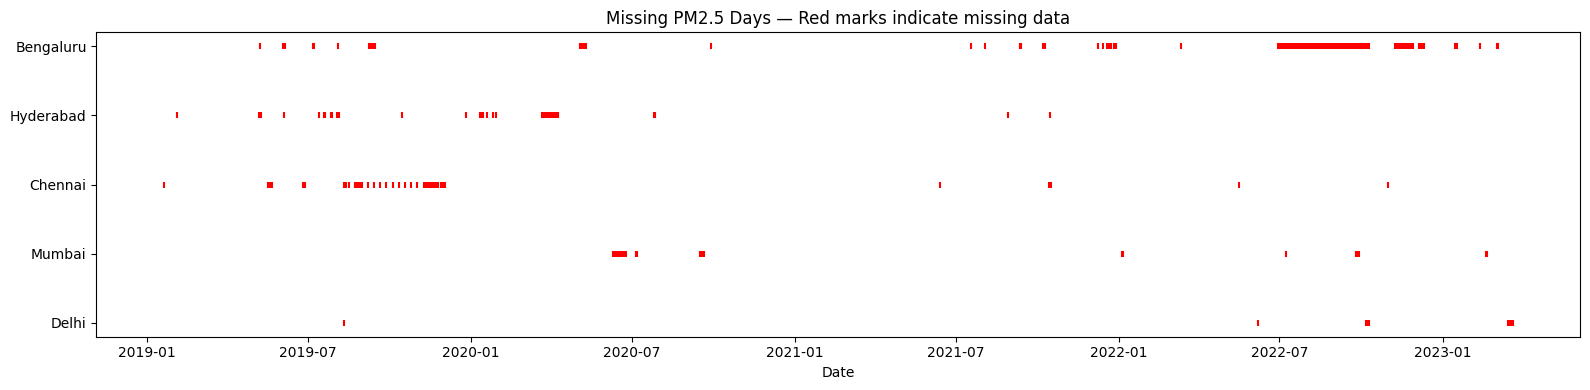

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(16, 4))

cities_order = ['Delhi', 'Mumbai', 'Chennai', 'Hyderabad', 'Bengaluru']

for i, city in enumerate(cities_order):
    df = kaggle_dfs[city]
    missing_mask = df['pm25'].isna().astype(int).values  # 1 = missing, 0 = present

    # Plot as a strip: red where missing, nothing where present
    dates = df['date'].values
    ax.scatter(dates[missing_mask == 1], [i] * missing_mask.sum(),
               marker='|', color='red', s=20)

ax.set_yticks(range(len(cities_order)))
ax.set_yticklabels(cities_order)
ax.set_xlabel('Date')
ax.set_title('Missing PM2.5 Days — Red marks indicate missing data')
plt.tight_layout()
plt.show()

In [25]:
del kaggle_dfs['Bengaluru']

print("Final city list:", list(kaggle_dfs.keys()))
for city, df in kaggle_dfs.items():
    missing_pct = df['pm25'].isna().mean() * 100
    print(f"  {city}: {len(df)} days, {missing_pct:.1f}% missing")

Final city list: ['Delhi', 'Mumbai', 'Chennai', 'Hyderabad']
  Delhi: 1551 days, 0.8% missing
  Mumbai: 1381 days, 2.4% missing
  Chennai: 1551 days, 3.9% missing
  Hyderabad: 1551 days, 2.9% missing


In [26]:
cities_to_check = ['Delhi', 'Chennai', 'Hyderabad', 'Bengaluru']

best_2019_stations = {}

for city in cities_to_check:
    candidates = stations_info[stations_info['city'] == city]['file_name'].tolist()

    best_file, best_count, best_total = None, 0, 0

    for fname in candidates:
        df = pd.read_csv(f'/content/air_quality/{fname}.csv')
        pm25_col = [c for c in df.columns if 'PM2.5' in c]
        if not pm25_col:
            continue

        df = df[['From Date', pm25_col[0]]].copy()
        df.columns = ['date', 'pm25']
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.dropna(subset=['date']).set_index('date')

        daily = df['pm25'].resample('D').mean().reset_index()
        daily.columns = ['date', 'pm25']

        daily_recent = daily[daily['date'] >= '2019-01-01']

        if len(daily_recent) == 0:
            continue

        non_null = daily_recent['pm25'].notna().sum()
        total = len(daily_recent)

        if non_null > best_count:
            best_count = non_null
            best_total = total
            best_file = fname

    pct_missing = (1 - best_count / best_total) * 100 if best_total else None
    best_2019_stations[city] = (best_file, best_count, best_total, pct_missing)
    print(f"{city}: best={best_file} | non-null={best_count}/{best_total} ({pct_missing:.1f}% missing)")

Delhi: best=DL030 | non-null=1550/1551 (0.1% missing)
Chennai: best=TN003 | non-null=1528/1551 (1.5% missing)
Hyderabad: best=TG004 | non-null=1531/1551 (1.3% missing)
Bengaluru: best=KA008 | non-null=1513/1551 (2.5% missing)


In [27]:
final_cities = {
    "Delhi" : "DL030",
    "Mumbai" : "MH015",
    "Chennai" : "TN003",
    "Hyderabad" : "TG004",
    "Bengaluru" : "KA008"
}

kaggle_dfs = {}

for city, fname in final_cities.items():
  df = pd.read_csv(f"/content/air_quality/{fname}.csv")
  pm25_col = [c for c in df.columns if "PM2.5" in c][0]
  df = df[["From Date", pm25_col]].copy()
  df.columns = ["date", "pm25"]
  df["date"] = pd.to_datetime(df["date"], errors = "coerce")
  df = df.dropna(subset = ["date"]).set_index("date")

  daily = df["pm25"].resample("D").mean().reset_index()
  daily.columns = ["date", "pm25"]

  daily = daily[daily["date"] >= "2019-01-01"].reset_index(drop = True)
  kaggle_dfs[city] = daily

for city, df in kaggle_dfs.items():
  print(f"{city}: {len(df)} days | missing={df['pm25'].isna().sum()} ({df['pm25'].isna().mean()*100:.1f}%) | range: {df['date'].min().date()} to {df['date'].max().date()}")

Delhi: 1551 days | missing=1 (0.1%) | range: 2019-01-01 to 2023-03-31
Mumbai: 1381 days | missing=33 (2.4%) | range: 2019-06-20 to 2023-03-31
Chennai: 1551 days | missing=23 (1.5%) | range: 2019-01-01 to 2023-03-31
Hyderabad: 1551 days | missing=20 (1.3%) | range: 2019-01-01 to 2023-03-31
Bengaluru: 1551 days | missing=38 (2.5%) | range: 2019-01-01 to 2023-03-31


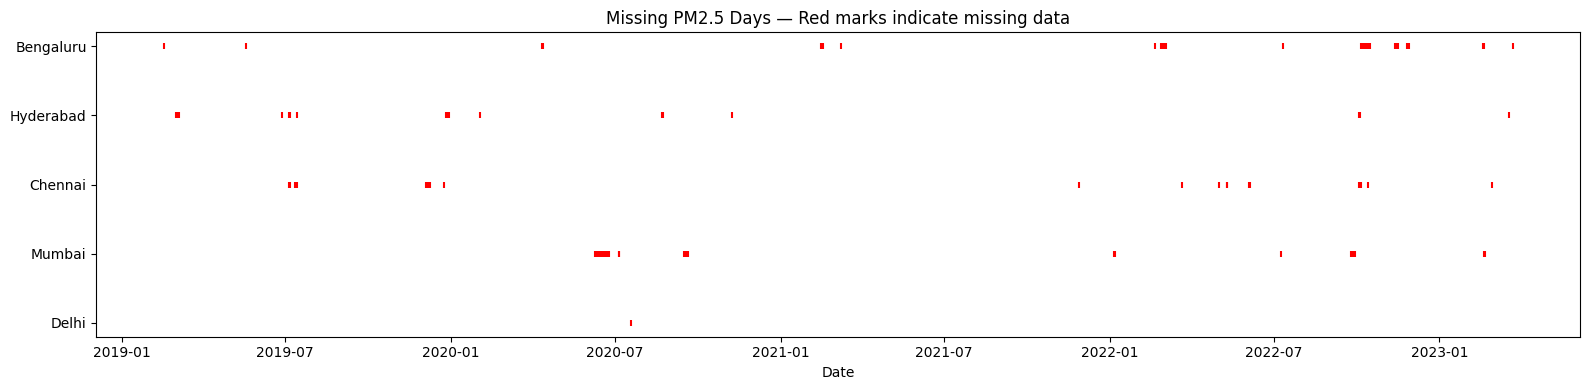

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (16,4))
cities_order = ['Delhi', 'Mumbai', 'Chennai', 'Hyderabad', 'Bengaluru']

for i, city in enumerate(cities_order):
  df = kaggle_dfs[city]
  missing_mask = df["pm25"].isna().astype(int).values
  dates = df["date"].values
  ax.scatter(dates[missing_mask == 1], [i] * missing_mask.sum(), marker = "|", color = "red", s = 20)

ax.set_yticks(range(len(cities_order)))
ax.set_yticklabels(cities_order)
ax.set_xlabel('Date')
ax.set_title('Missing PM2.5 Days — Red marks indicate missing data')
plt.tight_layout()
plt.show()

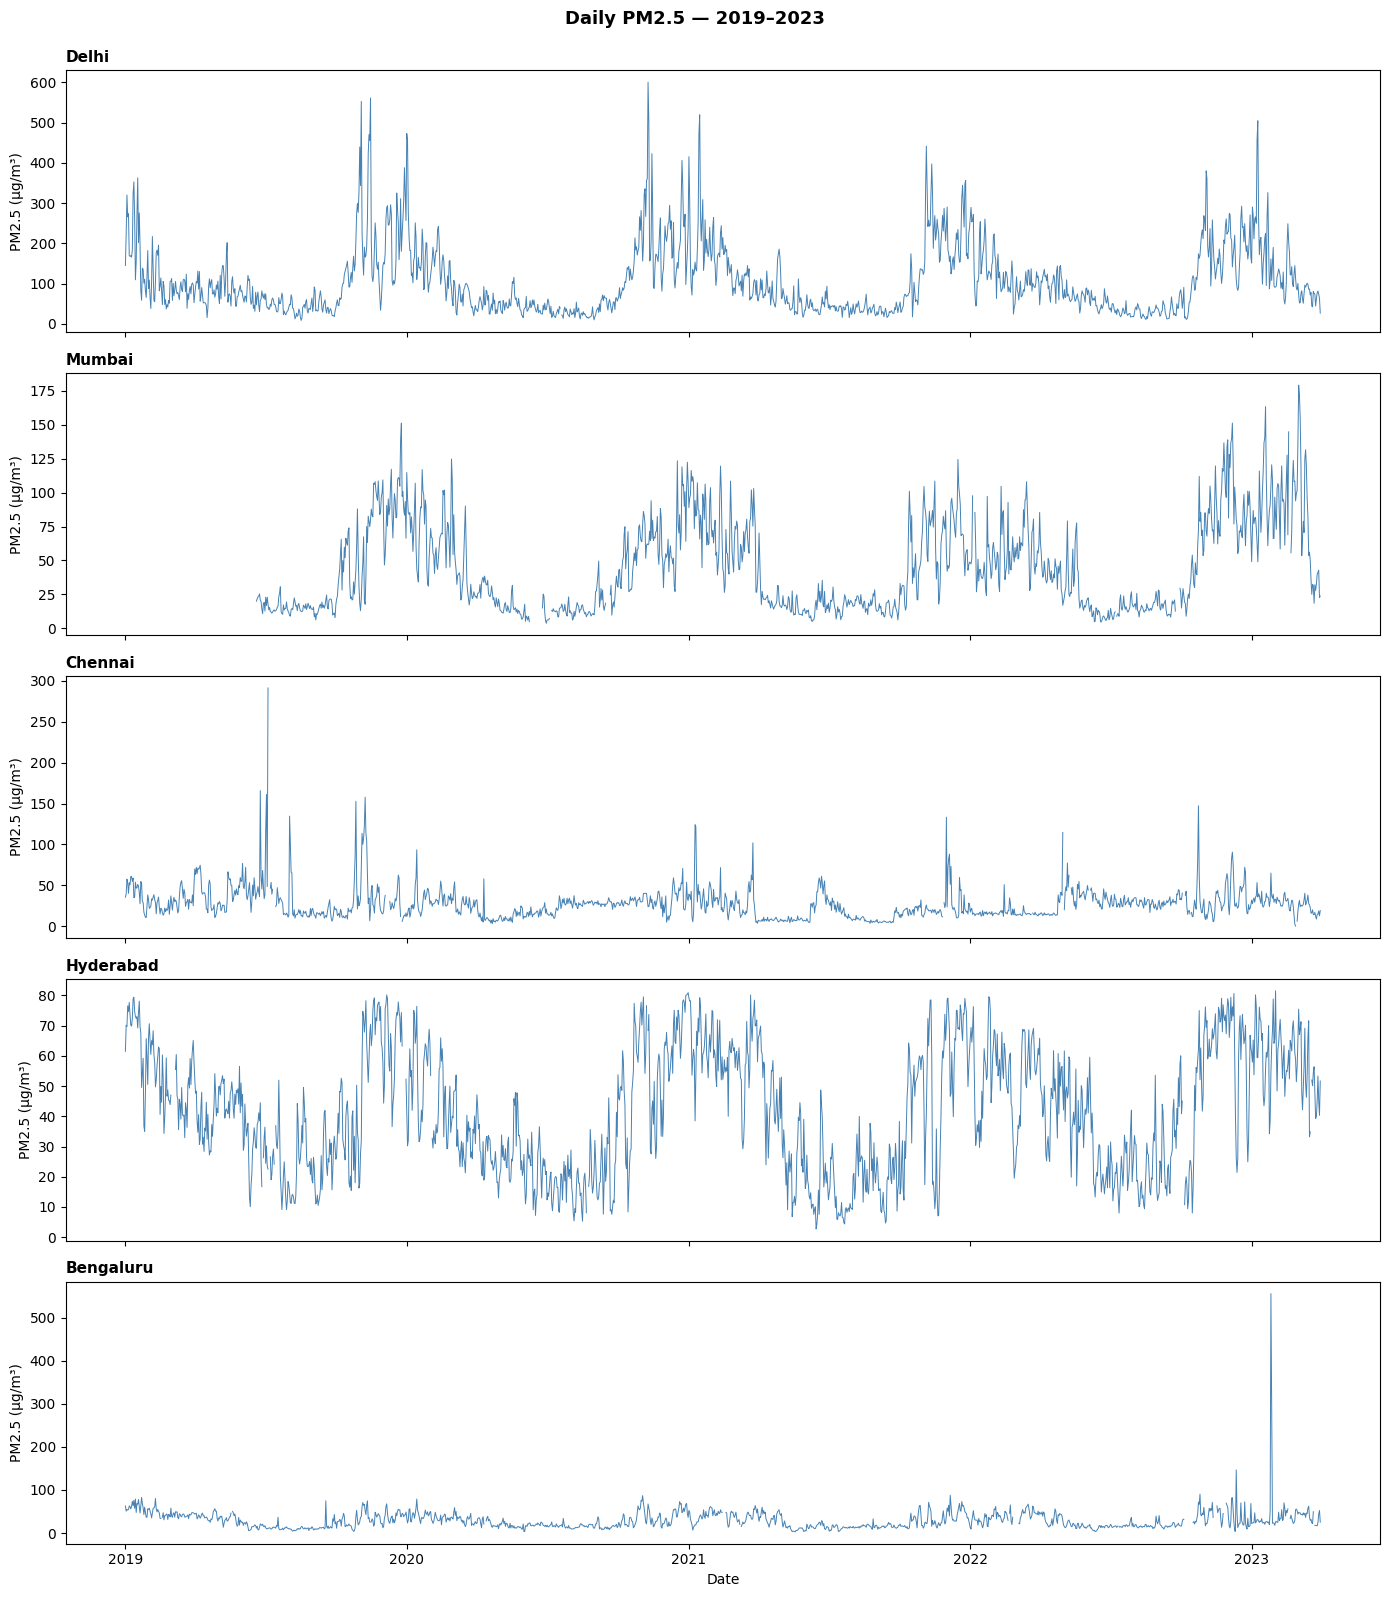

In [29]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(5, 1, figsize = (14,16), sharex = True)

cities_order = ["Delhi", "Mumbai", "Chennai", "Hyderabad", "Bengaluru"]

for ax, city in zip(axes, cities_order):
  df = kaggle_dfs[city]
  ax.plot(df["date"], df["pm25"], linewidth = 0.7, color = "steelblue")
  ax.set_title(city, fontsize = 11, fontweight = "bold", loc = "left")
  ax.set_ylabel('PM2.5 (µg/m³)')

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Date")

fig.suptitle('Daily PM2.5 — 2019–2023', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [30]:
bgl = kaggle_dfs["Bengaluru"]
bgl_spike = bgl.nlargest(5, "pm25")
print("Bengaluru — top 5 PM2.5 days:")
print(bgl_spike)

print()

chn = kaggle_dfs['Chennai']
chn_spike = chn.nlargest(5, 'pm25')
print("Chennai — top 5 PM2.5 days:")
print(chn_spike)

Bengaluru — top 5 PM2.5 days:
           date        pm25
1486 2023-01-26  556.000000
1487 2023-01-27  278.226190
1441 2022-12-12  146.484545
1394 2022-10-26   90.156250
1070 2021-12-06   87.813846

Chennai — top 5 PM2.5 days:
          date        pm25
185 2019-07-05  291.490588
175 2019-06-25  165.844583
183 2019-07-03  161.146250
311 2019-11-08  157.783750
299 2019-10-27  152.714583


In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

cities_order = ['Delhi', 'Mumbai', 'Chennai', 'Hyderabad', 'Bengaluru']

for city in cities_order:
  df = kaggle_dfs[city].copy()
  df = df.set_index('date')

  series = df["pm25"].interpolate(method = "linear")

  additive = seasonal_decompose(series, model = "additive", period = 365)
  multiplicative = seasonal_decompose(series, model = "multiplicative", period = 365)

  add_resid_std = additive.resid.std()
  mult_resid_std = multiplicative.resid.std()

  print(f"{city}:")
  print(f"  Additive residual std:       {add_resid_std:.2f}")
  print(f"  Multiplicative residual std: {mult_resid_std:.4f}")
  print()

Delhi:
  Additive residual std:       40.60
  Multiplicative residual std: 0.3248

Mumbai:
  Additive residual std:       13.87
  Multiplicative residual std: 0.3250

Chennai:
  Additive residual std:       16.35
  Multiplicative residual std: 0.4646

Hyderabad:
  Additive residual std:       11.02
  Multiplicative residual std: 0.3286

Bengaluru:
  Additive residual std:       9.00
  Multiplicative residual std: 0.3192



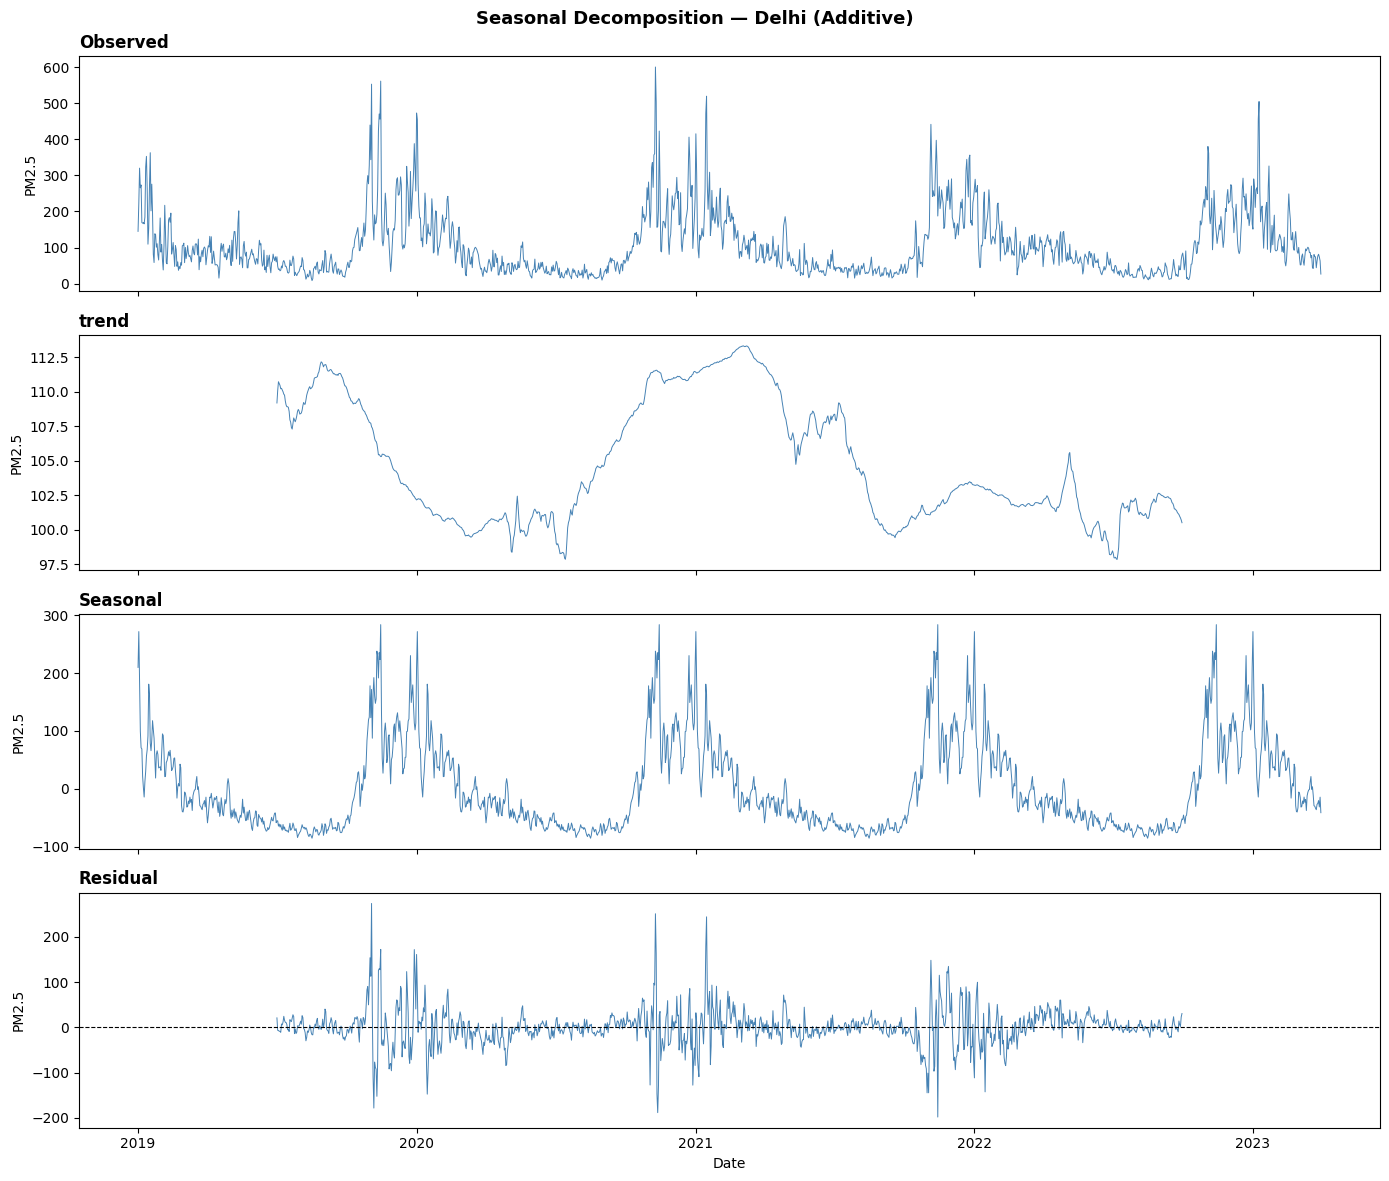

In [35]:
city = "Delhi"
df = kaggle_dfs[city].copy()
df = df.set_index("date")
series = df["pm25"].interpolate("linear")

result = seasonal_decompose(series, model = "additive", period = 365)

fig, axes = plt.subplots(4, 1, figsize = (14, 12), sharex = True)

axes[0].plot(result.observed, linewidth = 0.7, color = "steelblue")
axes[0].set_title("Observed", loc = "left", fontweight = "bold")
axes[0].set_ylabel("PM2.5")

axes[1].plot(result.trend, linewidth = 0.7, color = "steelblue")
axes[1].set_title("trend", loc = "left", fontweight = "bold")
axes[1].set_ylabel("PM2.5")

axes[2].plot(result.seasonal, linewidth = 0.7, color = "steelblue")
axes[2].set_title("Seasonal", loc = "left", fontweight = "bold")
axes[2].set_ylabel("PM2.5")

axes[3].plot(result.resid, linewidth = 0.7, color = "steelblue")
axes[3].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_title("Residual", loc = "left", fontweight = "bold")
axes[3].set_ylabel("PM2.5")

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Date')

fig.suptitle('Seasonal Decomposition — Delhi (Additive)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

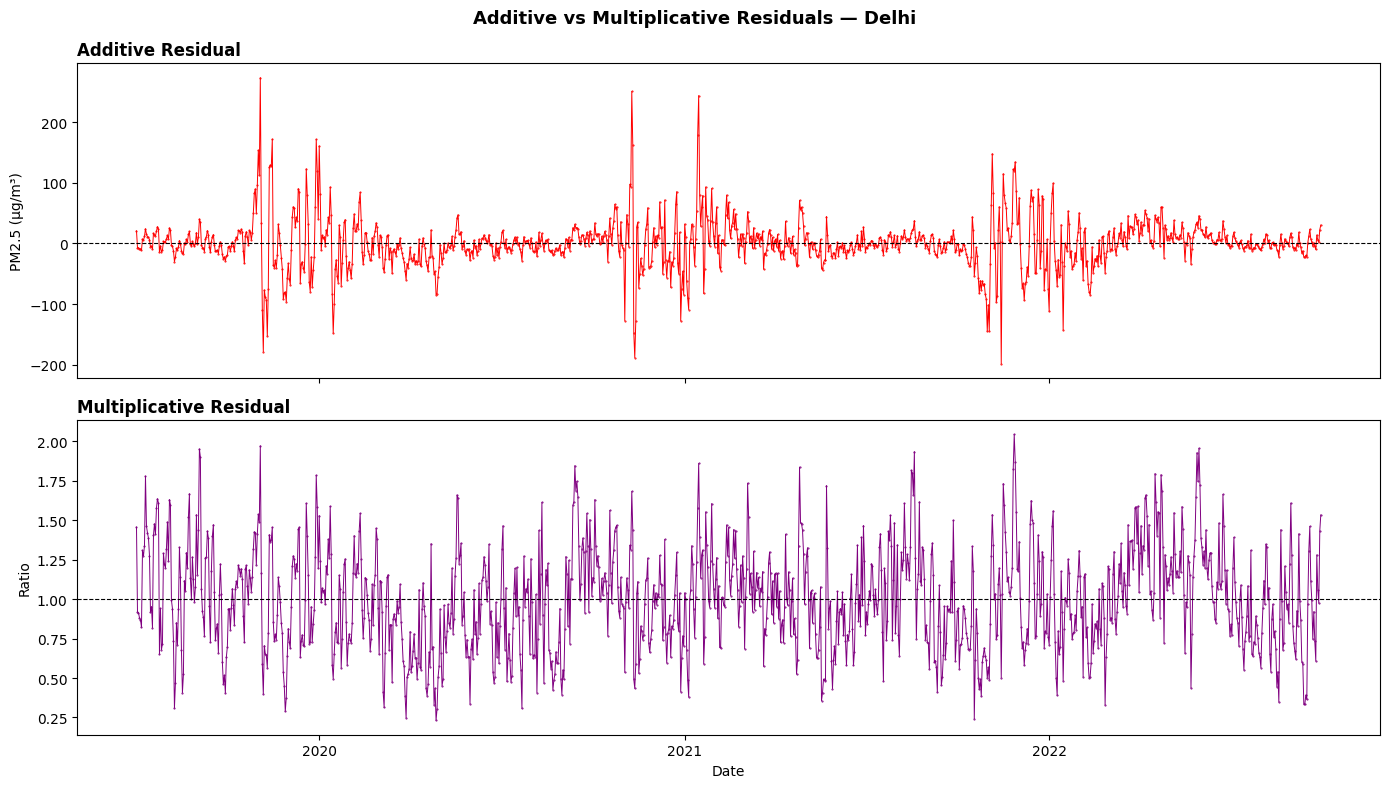

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

add_result = seasonal_decompose(series, model='additive', period=365)
axes[0].plot(add_result.resid, linewidth=0.7, color='red', marker='.', markersize=1)
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Additive Residual', loc='left', fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')

mult_result = seasonal_decompose(series, model='multiplicative', period=365)
axes[1].plot(mult_result.resid, linewidth=0.7, color='purple', marker='.', markersize=1)
axes[1].axhline(y=1, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Multiplicative Residual', loc='left', fontweight='bold')
axes[1].set_ylabel('Ratio')

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Date')

fig.suptitle('Additive vs Multiplicative Residuals — Delhi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

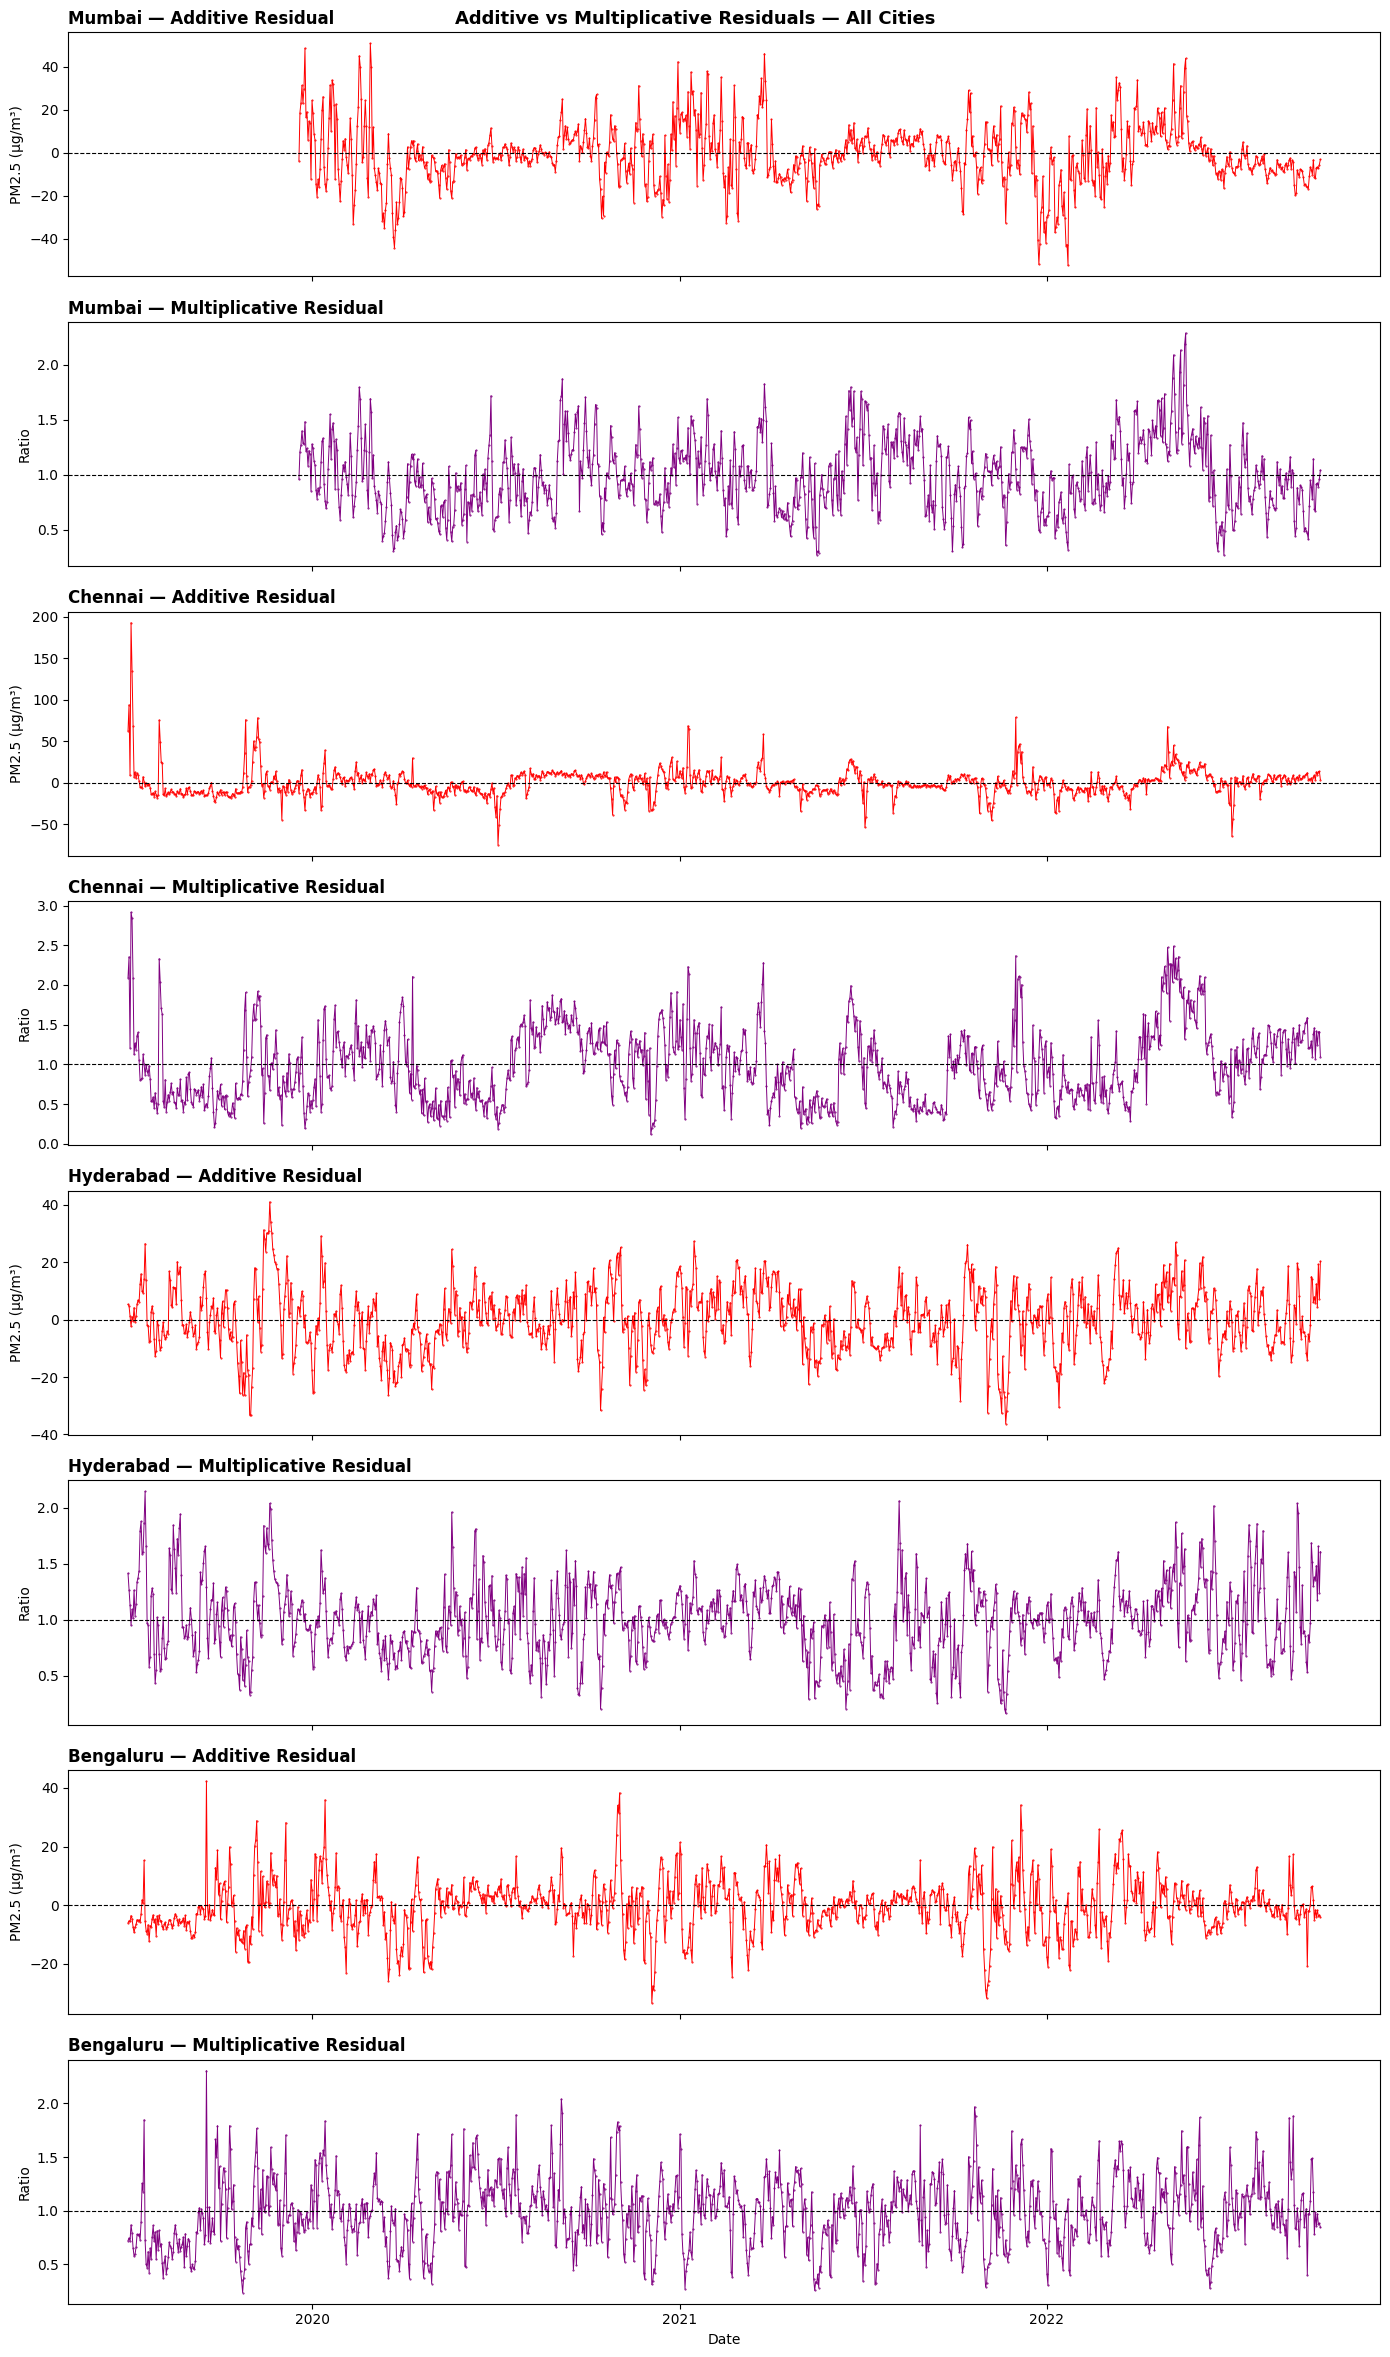

In [37]:
fig, axes = plt.subplots(8, 1, figsize=(14, 24), sharex=True)

cities_order = ['Mumbai', 'Chennai', 'Hyderabad', 'Bengaluru']

for i, city in enumerate(cities_order):
    df = kaggle_dfs[city].copy()
    df = df.set_index('date')
    series = df['pm25'].interpolate(method='linear')

    add_result = seasonal_decompose(series, model='additive', period=365)
    mult_result = seasonal_decompose(series, model='multiplicative', period=365)

    axes[i*2].plot(add_result.resid, linewidth=0.7, color='red', marker='.', markersize=1)
    axes[i*2].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    axes[i*2].set_title(f'{city} — Additive Residual', loc='left', fontweight='bold')
    axes[i*2].set_ylabel('PM2.5 (µg/m³)')

    axes[i*2+1].plot(mult_result.resid, linewidth=0.7, color='purple', marker='.', markersize=1)
    axes[i*2+1].axhline(y=1, color='black', linewidth=0.8, linestyle='--')
    axes[i*2+1].set_title(f'{city} — Multiplicative Residual', loc='left', fontweight='bold')
    axes[i*2+1].set_ylabel('Ratio')

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Date')

fig.suptitle('Additive vs Multiplicative Residuals — All Cities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3767/618331868.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_per_city, labels=cities_order, patch_artist=True)


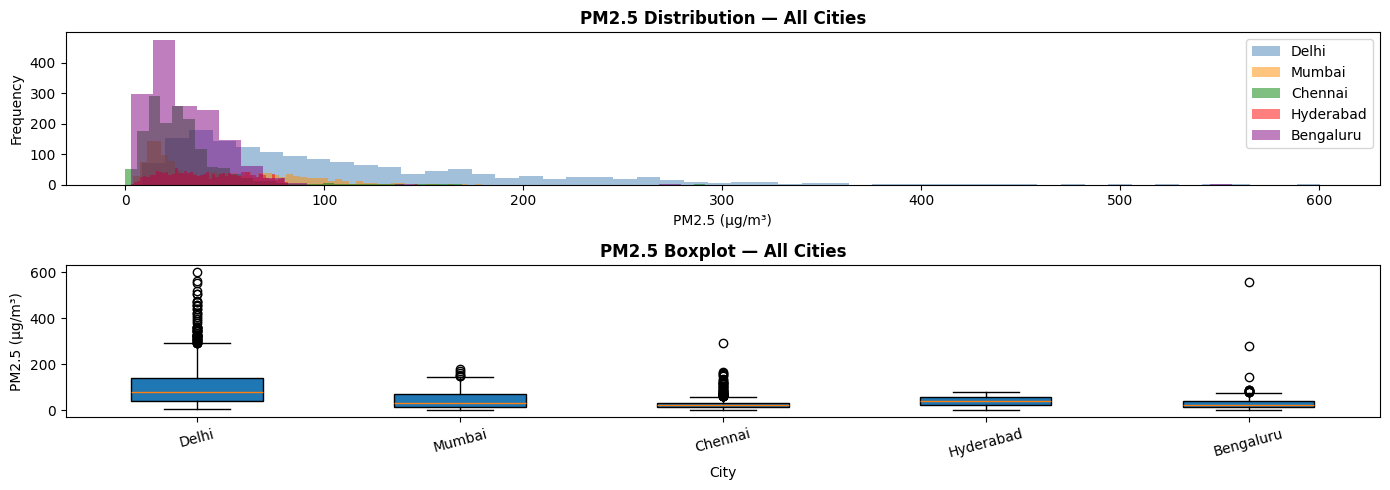

In [39]:
fig, axes = plt.subplots(2,1, figsize = (14,5))

cities_order = ['Delhi', 'Mumbai', 'Chennai', 'Hyderabad', 'Bengaluru']
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

for city, color in zip(cities_order, colors):
  df = kaggle_dfs[city]
  axes[0].hist(df["pm25"].dropna(), bins = 50, alpha = 0.5, label = city, color = color)

axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('PM2.5 Distribution — All Cities', fontweight='bold')
axes[0].legend()

data_per_city = [kaggle_dfs[city]['pm25'].dropna().values for city in cities_order]
axes[1].boxplot(data_per_city, labels=cities_order, patch_artist=True)
axes[1].set_xlabel('City')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_title('PM2.5 Boxplot — All Cities', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [40]:
import pandas as pd

combined = pd.DataFrame()

for city, df in kaggle_dfs.items():
  combined[city] = df.set_index("date")["pm25"]

In [44]:
corr_matrix = combined.corr()

print(corr_matrix.round(2))

           Delhi  Mumbai  Chennai  Hyderabad  Bengaluru
Delhi       1.00    0.60     0.16       0.60       0.35
Mumbai      0.60    1.00     0.16       0.71       0.44
Chennai     0.16    0.16     1.00       0.22       0.20
Hyderabad   0.60    0.71     0.22       1.00       0.50
Bengaluru   0.35    0.44     0.20       0.50       1.00


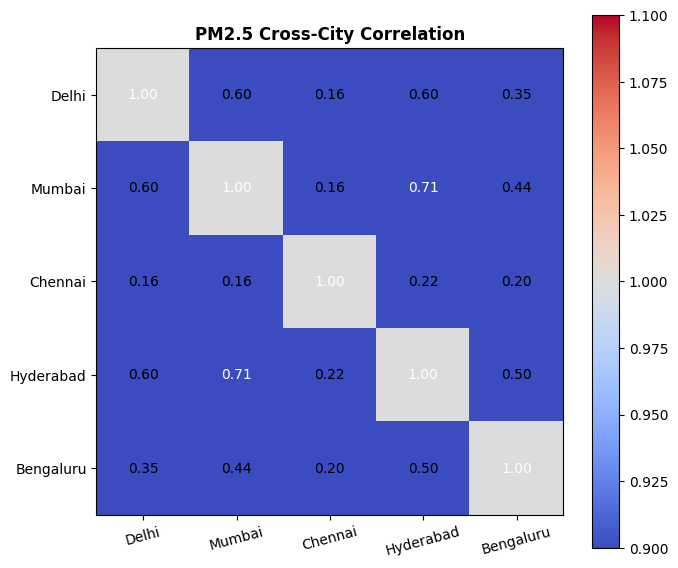